# EMG 4동작 분류 · 테스트

실습 2 축약판. 보드 연결 → 캘리브레이션 → 학습 → 실시간 판정.

동작 4개를 `1, 2, 3, 4` 로 할당. `GESTURES` 에서 이름만 바꾸면 됨.

In [1]:
# ===== 0. 준비 + 설정 (여기만 고치면 됨) =====
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
from collections import deque, Counter
from IPython.display import clear_output

from scipy import signal as sp_signal
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds

# 한글 폰트 (glyph 경고 제거)
from matplotlib import font_manager
_fonts = {f.name for f in font_manager.fontManager.ttflist}
for _c in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans KR', 'Gulim']:
    if _c in _fonts:
        plt.rcParams['font.family'] = _c
        break
plt.rcParams['axes.unicode_minus'] = False

# ---------------- 설정 ----------------
COM_PORT = 'COM5'

GESTURES = {
    1: 'Action1',
    2: 'Action2',
    3: 'Action3',
    4: 'Action4',
}

N_REPEAT   = 40      # 동작당 샘플 수 (약 10초)
NOTCH_FREQ = 60.0
BAND       = (30.0, 95.0)
# --------------------------------------

BOARD_ID = BoardIds.GANGLION_BOARD
FS       = BoardShim.get_sampling_rate(BOARD_ID)
EMG_CH   = BoardShim.get_eeg_channels(BOARD_ID)
N_CH     = len(EMG_CH)
WINDOW_SAMPLES = 100     # 0.5초

# 필터 계수 (한 번만 설계)
_nyq = FS / 2
b_notch, a_notch = sp_signal.iirnotch(NOTCH_FREQ / _nyq, Q=30)
b_band,  a_band  = sp_signal.butter(4, [BAND[0]/_nyq, BAND[1]/_nyq], btype='band')


def extract_features(window):
    """원시 EMG 창 (samples, ch) -> 채널별 포락선 평균 (ch,)"""
    x = sp_signal.filtfilt(b_notch, a_notch, window, axis=0)
    x = sp_signal.filtfilt(b_band,  a_band,  x,      axis=0)
    return np.abs(sp_signal.hilbert(x, axis=0)).mean(axis=0)


print('설정 완료')
print(f'  포트   : {COM_PORT}')
print(f'  샘플링 : {FS} Hz, 채널 {N_CH}개 {EMG_CH}')
print(f'  창     : {WINDOW_SAMPLES} 샘플 ({WINDOW_SAMPLES/FS:.2f}초)')
print(f'  필터   : {NOTCH_FREQ:.0f} Hz 노치 + {BAND[0]:.0f}-{BAND[1]:.0f} Hz 대역통과')
print(f'  동작   : {GESTURES}')
print(f'  반복   : 동작당 {N_REPEAT}회')

설정 완료
  포트   : COM5
  샘플링 : 200 Hz, 채널 4개 [1, 2, 3, 4]
  창     : 100 샘플 (0.50초)
  필터   : 60 Hz 노치 + 30-95 Hz 대역통과
  동작   : {1: 'Action1', 2: 'Action2', 3: 'Action3', 4: 'Action4'}
  반복   : 동작당 40회


In [2]:
# ===== 1. 보드 연결 =====
BoardShim.disable_board_logger()

params = BrainFlowInputParams()
params.serial_port = COM_PORT
params.timeout     = 40

board     = BoardShim(BOARD_ID, params)
connected = False

for attempt in range(1, 4):
    t0 = time.time()
    try:
        board.prepare_session()
        connected = True
        print(f'[{attempt}/3] 연결 성공 ({time.time()-t0:.1f}초)')
        break
    except Exception as e:
        print(f'[{attempt}/3] 실패 ({time.time()-t0:.1f}초): {e}')
        try:
            board.release_session()
        except Exception:
            pass
        if attempt < 3:
            time.sleep(3)

if connected:
    board.start_stream(450000, '')
    print('스트리밍 시작')
else:
    print('연결 실패. OpenBCI GUI 종료 / 다른 커널 종료 확인.')

[1/3] 연결 성공 (1.5초)
스트리밍 시작


KeyboardInterrupt: 

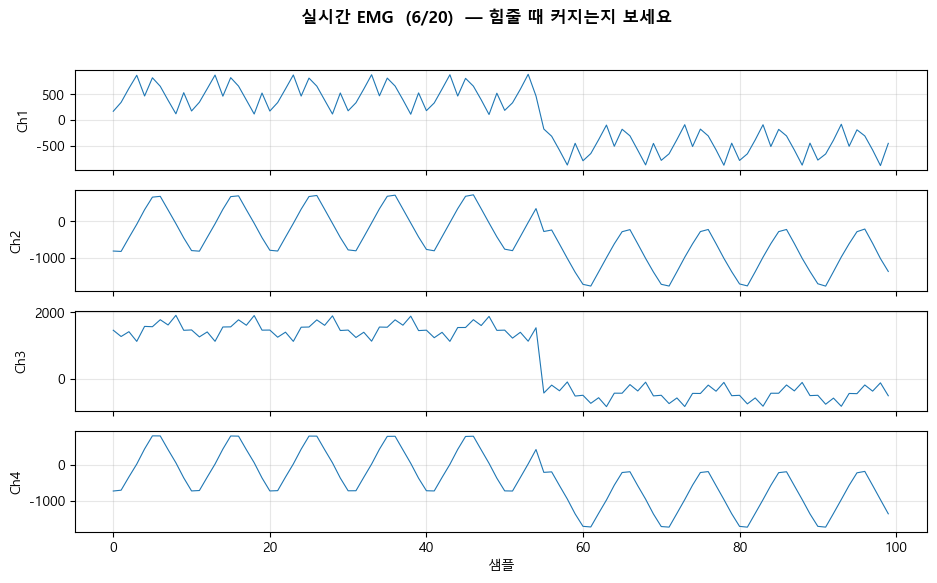

In [3]:
# ===== 2. 신호 확인 (10초) — 힘줄 때 커지는지 =====
if not connected:
    print('보드가 연결되지 않았습니다.')
else:
    print('10초간 실시간 신호. 동작을 취해 보세요.')
    n_frames = 20
    for frame in range(n_frames):
        time.sleep(0.5)
        d = board.get_current_board_data(WINDOW_SAMPLES)
        if d.shape[1] < 2:
            continue
        emg = d[EMG_CH, :]

        clear_output(wait=True)
        fig, axes = plt.subplots(N_CH, 1, figsize=(11, 6), sharex=True)
        fig.suptitle(f'실시간 EMG  ({frame+1}/{n_frames})  — 힘줄 때 커지는지 보세요',
                     fontweight='bold')
        for i in range(N_CH):
            axes[i].plot(emg[i], linewidth=0.8)
            axes[i].set_ylabel(f'Ch{i+1}')
            axes[i].grid(alpha=0.3)
        axes[-1].set_xlabel('샘플')
        plt.tight_layout()
        plt.show()

    print('반응이 있었다면 다음 셀로. 없으면 전극 다시 붙이고 재실행.')

In [4]:
# ===== 3. 캘리브레이션 (동작당 40회, 약 10초) =====
if not connected:
    print('보드가 연결되지 않았습니다.')
else:
    def collect_gesture(label, name, n_repeat):
        clear_output(wait=True)
        print(f'>>> 준비: [{label}] {name}')
        for c in (3, 2, 1):
            print(f'    {c}...')
            time.sleep(1)
        print(f'    시작! {name} 자세를 유지하세요')

        feats = np.zeros((n_repeat, N_CH))
        for i in range(n_repeat):
            d = board.get_current_board_data(WINDOW_SAMPLES)
            feats[i] = extract_features(d[EMG_CH, :].T)
            time.sleep(0.25)

            pct = (i + 1) / n_repeat
            bar = '█' * int(30 * pct) + '░' * (30 - int(30 * pct))
            clear_output(wait=True)
            print(f'>>> [{label}] {name}  자세 유지')
            print(f'    [{bar}] {pct*100:3.0f}%  ({i+1}/{n_repeat})')
        return feats

    board.get_board_data()   # 버퍼 비우기

    X_list, Y_list = [], []
    for label, name in GESTURES.items():
        feats = collect_gesture(label, name, N_REPEAT)
        X_list.append(feats)
        Y_list.append(np.full(N_REPEAT, label))

    X = np.vstack(X_list)
    Y = np.concatenate(Y_list)

    clear_output(wait=True)
    print('캘리브레이션 완료')
    print(f'  특징 행렬 : {X.shape}')
    print(f'  라벨      : {Y.shape}')
    for label, name in GESTURES.items():
        print(f'  [{label}] {name:10s} 평균 {X[Y==label].mean(axis=0).round(1)}')

캘리브레이션 완료
  특징 행렬 : (160, 4)
  라벨      : (160,)
  [1] Action1    평균 [253.9 289.7 458.4 242.8]
  [2] Action2    평균 [268.9 264.8 309.4 257.3]
  [3] Action3    평균 [337.1 297.8 292.8 165.8]
  [4] Action4    평균 [240.  311.8 391.8 290.3]


학습 128개 / 시험 32개
시험 정확도 : 50.0%


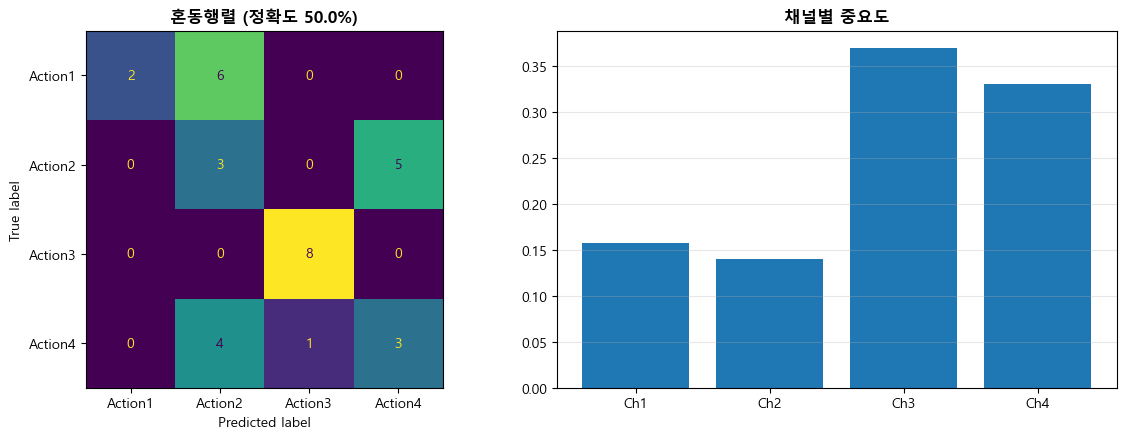

In [5]:
# ===== 4. 학습 + 평가 (시간순 분할) =====
if 'X' not in dir():
    print('먼저 캘리브레이션을 실행하세요.')
else:
    train_idx, test_idx = [], []
    for label in GESTURES:
        idx = np.where(Y == label)[0]
        cut = int(len(idx) * 0.8)
        train_idx.extend(idx[:cut])
        test_idx.extend(idx[cut:])
    train_idx = np.array(train_idx)
    test_idx  = np.array(test_idx)

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X[train_idx], Y[train_idx])

    Y_pred   = clf.predict(X[test_idx])
    accuracy = (Y_pred == Y[test_idx]).mean() * 100

    print(f'학습 {len(train_idx)}개 / 시험 {len(test_idx)}개')
    print(f'시험 정확도 : {accuracy:.1f}%')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    labels_sorted = sorted(GESTURES)
    names_sorted  = [GESTURES[l] for l in labels_sorted]
    cm = confusion_matrix(Y[test_idx], Y_pred, labels=labels_sorted)
    ConfusionMatrixDisplay(cm, display_labels=names_sorted).plot(ax=ax1, colorbar=False)
    ax1.set_title(f'혼동행렬 (정확도 {accuracy:.1f}%)', fontweight='bold')

    ax2.bar([f'Ch{i+1}' for i in range(N_CH)], clf.feature_importances_)
    ax2.set_title('채널별 중요도', fontweight='bold')
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

프레임 120/120
  순간 예측 : [4] Action4
  안정 판정 : >>> [4] Action4 <<<
  [1] Action1                            0%
  [2] Action2    ███                    17%
  [3] Action3    █                       8%
  [4] Action4    ███████████████        75%


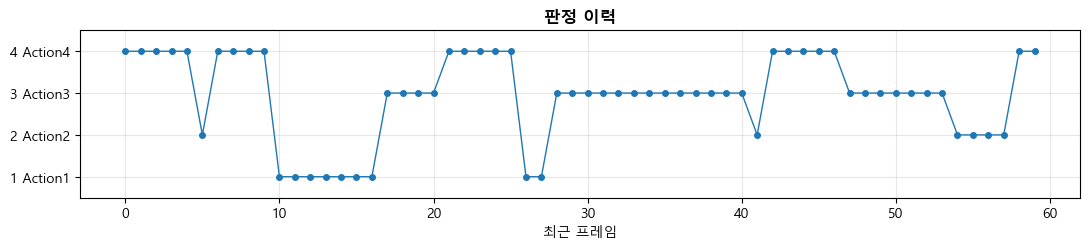


실시간 판정 종료.


In [20]:
# ===== 5. 실시간 판정 (다수결 안정화) =====
if 'clf' not in dir():
    print('먼저 모델을 학습하세요.')
elif not connected:
    print('보드가 연결되지 않았습니다.')
else:
    recent  = deque(maxlen=5)
    history = deque(maxlen=60)
    board.get_board_data()

    n_frames = 120     # 약 30초
    for frame in range(n_frames):
        d = board.get_current_board_data(WINDOW_SAMPLES)
        if d.shape[1] < WINDOW_SAMPLES:
            time.sleep(0.25)
            continue

        feat  = extract_features(d[EMG_CH, :].T).reshape(1, -1)
        proba = clf.predict_proba(feat)[0]
        pred  = int(clf.classes_[proba.argmax()])
        recent.append(pred)
        stable = Counter(recent).most_common(1)[0][0]
        history.append(stable)

        clear_output(wait=True)
        print(f'프레임 {frame+1}/{n_frames}')
        print('=' * 44)
        print(f'  순간 예측 : [{pred}] {GESTURES.get(pred, pred)}')
        print(f'  안정 판정 : >>> [{stable}] {GESTURES.get(stable, stable)} <<<')
        print('=' * 44)
        for l in sorted(GESTURES):
            p = proba[list(clf.classes_).index(l)] if l in clf.classes_ else 0.0
            print(f'  [{l}] {GESTURES[l]:10s} {"█"*int(p*20):<20} {p*100:4.0f}%')

        # 판정 이력 플롯
        fig, ax = plt.subplots(figsize=(11, 2.6))
        ax.plot(list(history), marker='o', markersize=4, linewidth=1)
        ax.set_ylim(min(GESTURES) - 0.5, max(GESTURES) + 0.5)
        ax.set_yticks(sorted(GESTURES))
        ax.set_yticklabels([f'{l} {GESTURES[l]}' for l in sorted(GESTURES)])
        ax.set_xlabel('최근 프레임')
        ax.set_title('판정 이력', fontweight='bold')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        time.sleep(0.25)

    print('\n실시간 판정 종료.')

---
# 6단계 · 판정 결과를 키보드 입력으로 내보내기

0.5초마다 안정 판정을 내고, 그 숫자(`1`/`2`/`3`/`4`)를 **가상 키 입력**으로 보냅니다.
지금 포커스가 있는 창(메모장 등)에 그대로 타이핑됩니다.

### 사용법
1. 메모장을 열어 둡니다
2. 아래 셀을 실행 → **5초 카운트다운** 동안 메모장을 클릭해 포커스를 옮깁니다
3. 동작을 취하면 메모장에 숫자가 찍힙니다

### 중단
- **ESC 키를 누르면 즉시 중지**합니다 (매 프레임 확인)
- 또는 `DURATION_SEC` 이 끝나면 자동 종료

> ⚠️ 포커스가 있는 **아무 창에나** 입력됩니다. 실행 중에는 메모장 외의 창
> (특히 이 노트북)을 클릭하지 마세요. 노트북에 포커스가 있으면 셀에 숫자가 들어갑니다.

> 🧪 `ONLY_ON_CHANGE = True` 면 판정이 **바뀔 때만** 입력합니다 (같은 숫자 도배 방지).
> `False` 면 0.5초마다 무조건 한 번씩 입력합니다.

In [6]:
# ===== 6-A. 키보드 출력 단독 테스트 (보드 없이) =====
# 아래 6단계 셀을 먼저 실행해서 함수들을 정의한 뒤, 이 셀로 키 입력만 확인한다.
# 메모장에 1234 가 찍히면 키보드 출력 자체는 정상.

if 'send_digit' not in dir():
    print('먼저 아래 「6. 판정 -> 키보드 출력」 셀을 한 번 실행하세요.')
    print('(모델이 없어도 함수 정의까지는 됩니다)')
else:
    print('5초 뒤 1,2,3,4 를 0.5초 간격으로 보냅니다.')
    print('지금 메모장을 클릭하세요!')
    for c in range(5, 0, -1):
        print(f'  {c}...')
        time.sleep(1)

    ok_all = True
    for n in [1, 2, 3, 4]:
        ok = send_digit(n)
        ok_all &= ok
        time.sleep(0.5)

    print()
    print(f'포커스 창 : {foreground_title()}')
    print(f'입력 방식 : {KEY_MODE}')
    print(f'SendInput : {"모두 성공" if ok_all else "실패 있음 (위 에러 참고)"}')
    print()
    print('메모장에 1234 가 찍혔나요?')
    print('  찍혔다  -> 정상. 6단계 셀을 실행하세요.')
    print('  안 찍혔다 -> 아래를 확인:')
    print('    1) 포커스 창 이름이 메모장이 맞는지 (위 출력 확인)')
    print('    2) KEY_MODE 를 \'vk\' 로 바꾸고 6단계 셀 재실행 후 이 셀 다시')
    print('    3) Jupyter 를 관리자 권한으로 켰다면 메모장도 관리자로 (권한 불일치 차단)')

먼저 아래 「6. 판정 -> 키보드 출력」 셀을 한 번 실행하세요.
(모델이 없어도 함수 정의까지는 됩니다)


In [ ]:
# ===== 6. 판정 -> 키보드 출력 =====
import ctypes
from ctypes import wintypes

# ---------------- 설정 ----------------
DURATION_SEC   = 60      # 총 실행 시간 (초)
EMIT_PERIOD    = 0.5     # 몇 초마다 한 번 판정/입력할지
ONLY_ON_CHANGE = False   # True: 판정이 바뀔 때만 / False: 매 주기마다
SEND_NEWLINE   = False   # True: 숫자 뒤에 Enter 도 같이
KEY_MODE       = 'scan'  # 'scan' 또는 'vk' (scan 이 안 먹으면 vk 로)
# --------------------------------------

# ---- Windows SendInput ----
user32 = ctypes.WinDLL('user32', use_last_error=True)

INPUT_KEYBOARD     = 1
KEYEVENTF_KEYUP    = 0x0002
KEYEVENTF_SCANCODE = 0x0008
VK_ESCAPE          = 0x1B

# 물리 키 위치 기준 스캔코드 / 가상키 코드
SCAN = {1: 0x02, 2: 0x03, 3: 0x04, 4: 0x05}
VK   = {1: 0x31, 2: 0x32, 3: 0x33, 4: 0x34}
SCAN_ENTER, VK_ENTER = 0x1C, 0x0D

ULONG_PTR = ctypes.c_ulonglong if ctypes.sizeof(ctypes.c_void_p) == 8 else ctypes.c_ulong


# INPUT 의 union 은 MOUSEINPUT / KEYBDINPUT / HARDWAREINPUT 셋 중 가장 큰 것 크기다.
# x64 에서 MOUSEINPUT 이 32바이트라 union 은 32바이트, INPUT 은 40바이트가 된다.
# 이 크기를 틀리게 잡으면 SendInput 이 ERROR_INVALID_PARAMETER(87) 로 실패한다.
# 그래서 세 구조체를 전부 정의해 크기를 컴파일러와 동일하게 맞춘다.
class MOUSEINPUT(ctypes.Structure):
    _fields_ = [('dx', wintypes.LONG), ('dy', wintypes.LONG),
                ('mouseData', wintypes.DWORD), ('dwFlags', wintypes.DWORD),
                ('time', wintypes.DWORD), ('dwExtraInfo', ULONG_PTR)]


class KEYBDINPUT(ctypes.Structure):
    _fields_ = [('wVk', wintypes.WORD), ('wScan', wintypes.WORD),
                ('dwFlags', wintypes.DWORD), ('time', wintypes.DWORD),
                ('dwExtraInfo', ULONG_PTR)]


class HARDWAREINPUT(ctypes.Structure):
    _fields_ = [('uMsg', wintypes.DWORD),
                ('wParamL', wintypes.WORD), ('wParamH', wintypes.WORD)]


class _INPUTunion(ctypes.Union):
    _fields_ = [('mi', MOUSEINPUT), ('ki', KEYBDINPUT), ('hi', HARDWAREINPUT)]


class INPUT(ctypes.Structure):
    _fields_ = [('type', wintypes.DWORD), ('u', _INPUTunion)]


# argtypes 를 지정하지 않으면 64비트에서 포인터가 잘려 역시 실패한다.
user32.SendInput.argtypes = (wintypes.UINT, ctypes.POINTER(INPUT), ctypes.c_int)
user32.SendInput.restype  = wintypes.UINT
user32.GetForegroundWindow.restype = wintypes.HWND
user32.GetWindowTextW.argtypes = (wintypes.HWND, wintypes.LPWSTR, ctypes.c_int)

_EXPECT = 40 if ctypes.sizeof(ctypes.c_void_p) == 8 else 28
print(f'sizeof(INPUT) = {ctypes.sizeof(INPUT)}  (기대값 {_EXPECT})')
if ctypes.sizeof(INPUT) != _EXPECT:
    print('  [!] 크기가 다릅니다. SendInput 이 87 에러로 실패합니다.')


def _key(code, up=False):
    if KEY_MODE == 'scan':
        flags = KEYEVENTF_SCANCODE | (KEYEVENTF_KEYUP if up else 0)
        ki = KEYBDINPUT(0, code, flags, 0, 0)
    else:
        flags = KEYEVENTF_KEYUP if up else 0
        ki = KEYBDINPUT(code, 0, flags, 0, 0)
    inp = INPUT()
    inp.type = INPUT_KEYBOARD
    inp.u.ki = ki
    return inp


def send_digit(n, newline=False):
    """숫자 n 을 지금 포커스된 창으로 보낸다. 성공하면 True"""
    code = SCAN[n] if KEY_MODE == 'scan' else VK[n]
    seq  = [_key(code, False), _key(code, True)]
    if newline:
        ec = SCAN_ENTER if KEY_MODE == 'scan' else VK_ENTER
        seq += [_key(ec, False), _key(ec, True)]
    arr  = (INPUT * len(seq))(*seq)
    sent = user32.SendInput(len(seq), arr, ctypes.sizeof(INPUT))
    if sent != len(seq):
        print(f'\n[!] SendInput 실패 ({sent}/{len(seq)}) '
              f'GetLastError={ctypes.get_last_error()}')
        return False
    return True


def foreground_title():
    """지금 포커스를 가진 창의 제목 - 키가 어디로 가는지 확인용"""
    buf = ctypes.create_unicode_buffer(256)
    user32.GetWindowTextW(user32.GetForegroundWindow(), buf, 256)
    return buf.value or '(제목 없음)'


def esc_pressed():
    return bool(user32.GetAsyncKeyState(VK_ESCAPE) & 0x8000)


# ---- 실행 ----
if 'clf' not in dir():
    print('먼저 모델을 학습하세요 (4단계).')
elif not connected:
    print('보드가 연결되지 않았습니다.')
else:
    print('=' * 60)
    print('키보드 출력 모드')
    print('=' * 60)
    print(f'  주기      : {EMIT_PERIOD}초마다')
    print(f'  총 시간   : {DURATION_SEC}초')
    print(f'  입력 조건 : {"판정이 바뀔 때만" if ONLY_ON_CHANGE else "매 주기마다"}')
    print(f'  입력 방식 : {KEY_MODE}')
    print(f'  중단      : ESC 키')
    print('=' * 60)
    for c in range(5, 0, -1):
        print(f'  {c}초 뒤 시작 - 지금 메모장을 클릭하세요!')
        time.sleep(1)

    recent   = deque(maxlen=5)
    log      = []
    last_key = None
    fails    = 0
    board.get_board_data()          # 버퍼 비우기

    t_end   = time.time() + DURATION_SEC
    aborted = False

    while time.time() < t_end:
        t_cycle = time.time()

        if esc_pressed():
            aborted = True
            break

        d = board.get_current_board_data(WINDOW_SAMPLES)
        if d.shape[1] < WINDOW_SAMPLES:
            time.sleep(0.05)
            continue

        feat   = extract_features(d[EMG_CH, :].T).reshape(1, -1)
        proba  = clf.predict_proba(feat)[0]
        pred   = int(clf.classes_[proba.argmax()])
        recent.append(pred)
        stable = Counter(recent).most_common(1)[0][0]

        sent = False
        if stable in SCAN and (not ONLY_ON_CHANGE or stable != last_key):
            if send_digit(stable, SEND_NEWLINE):
                sent = True
                log.append((datetime.now().strftime('%H:%M:%S'), stable))
            else:
                fails += 1
            last_key = stable

        remain = t_end - time.time()
        mark   = '-> KEY 전송' if sent else '           '
        # 포커스 창이 메모장이 아니면 키가 딴 데로 간 것이다.
        print(f'\r[{remain:5.1f}s] [{stable}] {GESTURES.get(stable, ""):9s} '
              f'{proba.max()*100:3.0f}% {mark} | 전송 {len(log)}회 '
              f'| 포커스: {foreground_title()[:28]:28s}', end='', flush=True)

        dt = EMIT_PERIOD - (time.time() - t_cycle)
        if dt > 0:
            time.sleep(dt)

    print()
    print()
    print('중단됨 (ESC)' if aborted else '종료 (시간 만료)')
    print(f'전송 성공 : {len(log)}회   실패 : {fails}회')
    if log:
        cnt = Counter(k for _, k in log)
        for l in sorted(GESTURES):
            print(f'  [{l}] {GESTURES[l]:10s} {cnt.get(l, 0):4d}회')
        print()
        print('마지막 10회:')
        for t, k in log[-10:]:
            print(f'  {t}  ->  {k} ({GESTURES.get(k, "")})')

sizeof(INPUT) = 40  (기대값 40)
키보드 출력 모드
  주기      : 0.5초마다
  총 시간   : 60초
  입력 조건 : 매 주기마다
  입력 방식 : scan
  중단      : ESC 키
  5초 뒤 시작 - 지금 메모장을 클릭하세요!
  4초 뒤 시작 - 지금 메모장을 클릭하세요!
  3초 뒤 시작 - 지금 메모장을 클릭하세요!
  2초 뒤 시작 - 지금 메모장을 클릭하세요!
  1초 뒤 시작 - 지금 메모장을 클릭하세요!
[ 56.5s] [1] Action1    43% -> KEY 전송 | 전송 7회 | 포커스: *222221 - 메모장               

In [ ]:
# ===== 6. 연결 해제 (꼭 실행) =====
try:
    if board.is_prepared():
        board.release_session()
        print('연결 해제 완료.')
    else:
        print('이미 해제되어 있습니다.')
except Exception as e:
    print(f'해제 중 문제: {e}')